'''TASK 2·Wine Quality Prediction
Objective:Train and compare multiple classification models to predict the quality score of wine based on its physicochemical properties such as acidity, density, and alcohol content.'''

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

'''1.Load the Wine Quality dataset and inspect structure; check class distribution of quality scores'''

In [2]:
df=pd.read_csv("C:/Users/Ayush Singh/OIBSIB/L2-winequality-red.csv")
print("Red Wine Dataset")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nInitial 5 Rows:")
print(df.head())

Red Wine Dataset
Shape: (1599, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Initial 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26      

'''2.EDA: distribution plots for all chemical features; correlation heatmap'''

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_25500\1180512049.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality',data=df,palette='viridis')


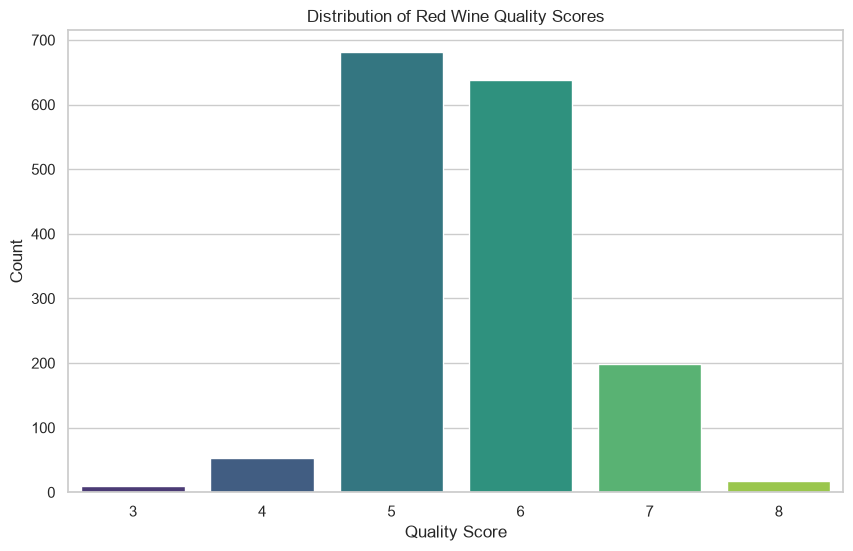

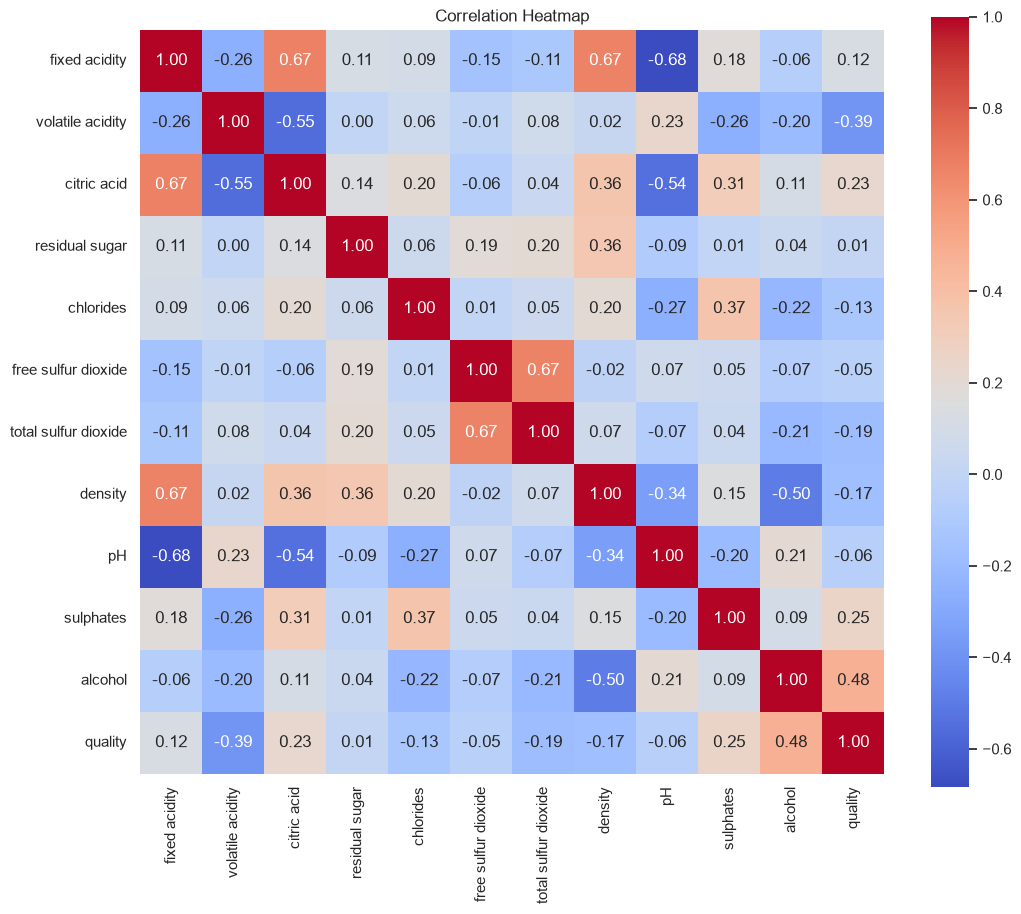

In [3]:
print(df['quality'].value_counts().sort_index())
plt.figure(figsize=(10,6))
sns.countplot(x='quality',data=df,palette='viridis')
plt.title('Distribution of Red Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(12,10)) #heatmap code here
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap='coolwarm',square=True)
plt.title('Correlation Heatmap')
plt.show()

'''3.Discuss class imbalance: are certain quality scores underrepresented? How does this affect modelling?'''

'''4.Feature engineering: consider binning quality scores into binary (good/bad) or 3-class (low/medium/high) groups and justify the decision'''


New Class Distribution
quality_class
Low       744
Medium    638
High      217
Name: count, dtype: int64


C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_25500\1128266527.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality_class',data=df,palette='plasma')


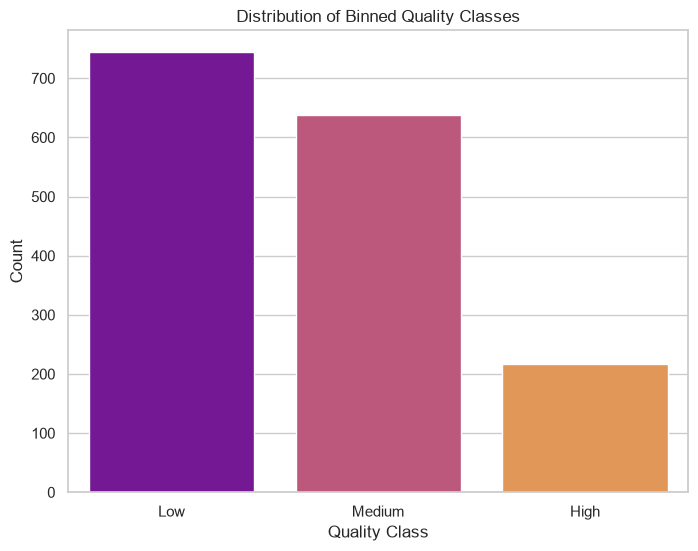

In [4]:
bins=[2,5,6,9]
labels=['Low','Medium','High']
df['quality_class']=pd.cut(df['quality'],bins=bins,labels=labels)
print("\nNew Class Distribution")
print(df['quality_class'].value_counts())
plt.figure(figsize=(8,6))
sns.countplot(x='quality_class',data=df,palette='plasma')
plt.title('Distribution of Binned Quality Classes')
plt.xlabel('Quality Class')
plt.ylabel('Count')
plt.show()
X=df.drop(['quality','quality_class'], axis=1)
y=df['quality_class']   

'''5.Train/test split'''

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(f"Training Set: {X_train.shape}, Test Set: {X_test.shape}")   

Training Set: (1279, 11), Test Set: (320, 11)


'''6.Train 3 classifiers: Random Forest, Stochastic Gradient Descent (SGD), and Support Vector Classifier (SVC)'''

In [6]:
rf_model= RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
sgd_model= SGDClassifier(loss='hinge',max_iter=1000,random_state=42,class_weight='balanced')
svc_model= SVC(kernel='rbf',C=10,gamma='scale',class_weight='balanced',random_state=42)
rf_model.fit(X_train, y_train)
sgd_model.fit(X_train_scaled, y_train)
svc_model.fit(X_train_scaled, y_train)
models= {
    'Random Forest': (rf_model, X_test),
    'SGD Classifier': (sgd_model, X_test_scaled),
    'SVC': (svc_model, X_test_scaled)
}   

'''7.Evaluate each: accuracy, classification report, confusion matrix'''


Random Forest (Accuracy: 0.7312)
              precision    recall  f1-score   support

        High       0.56      0.70      0.62        43
         Low       0.83      0.81      0.82       149
      Medium       0.69      0.66      0.67       128

    accuracy                           0.73       320
   macro avg       0.69      0.72      0.70       320
weighted avg       0.74      0.73      0.73       320



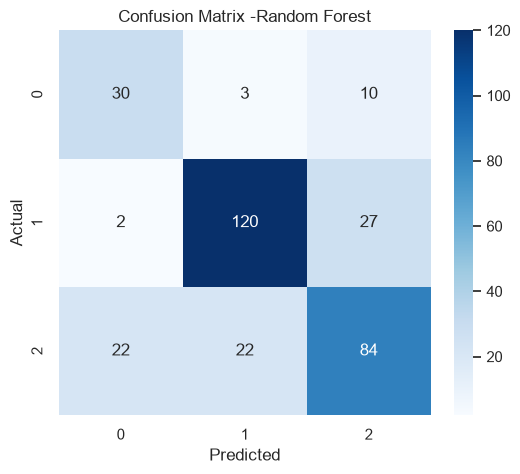


SGD Classifier (Accuracy: 0.5531)
              precision    recall  f1-score   support

        High       0.23      0.33      0.27        43
         Low       0.70      0.74      0.72       149
      Medium       0.51      0.41      0.45       128

    accuracy                           0.55       320
   macro avg       0.48      0.49      0.48       320
weighted avg       0.56      0.55      0.55       320



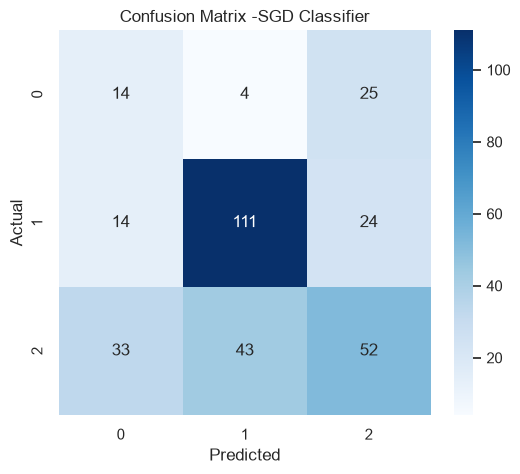


SVC (Accuracy: 0.6750)
              precision    recall  f1-score   support

        High       0.55      0.70      0.61        43
         Low       0.75      0.76      0.76       149
      Medium       0.63      0.57      0.60       128

    accuracy                           0.68       320
   macro avg       0.64      0.68      0.66       320
weighted avg       0.68      0.68      0.67       320



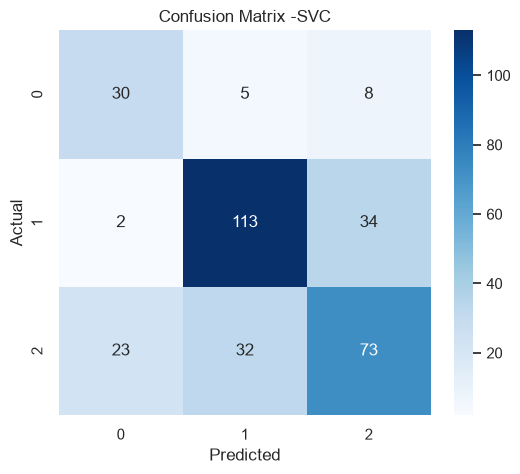

In [7]:
results = []
for name,(model, X_data) in models.items():
    y_pred=model.predict(X_data)
    acc= accuracy_score(y_test,y_pred)
    rep= classification_report(y_test,y_pred)
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Predictions': y_pred
    })
    print(f"\n{name} (Accuracy: {acc:.4f})")
    print(rep)
    plt.figure(figsize=(6,5))
    sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='Blues')
    plt.title(f'Confusion Matrix -{name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()   

'''8.Feature importance chart for the Random Forest model'''

C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_25500\2929263819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values,y=feature_importances.index,palette='viridis')


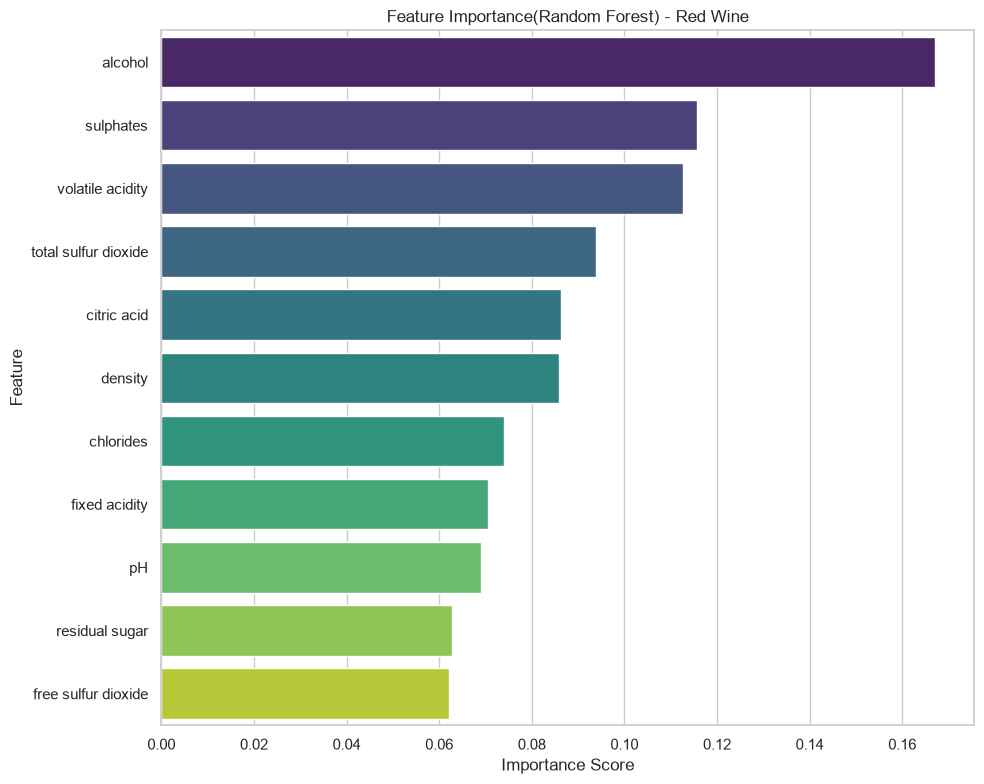

In [8]:
feature_importances=pd.Series(rf_model.feature_importances_,index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,8))
sns.barplot(x=feature_importances.values,y=feature_importances.index,palette='viridis')
plt.title('Feature Importance(Random Forest) - Red Wine')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()   

 '''9.Comparison table: summarise the performance of all 3 models side-by-side'''


Performance Comparison
                Accuracy  Precision (Wtd)  Recall (Wtd)  F1-Score (Wtd)
Model                                                                  
Random Forest   0.731250         0.737684      0.731250        0.733100
SGD Classifier  0.553125         0.563897      0.553125        0.554543
SVC             0.675000         0.677979      0.675000        0.674544


<Figure size 1000x600 with 0 Axes>

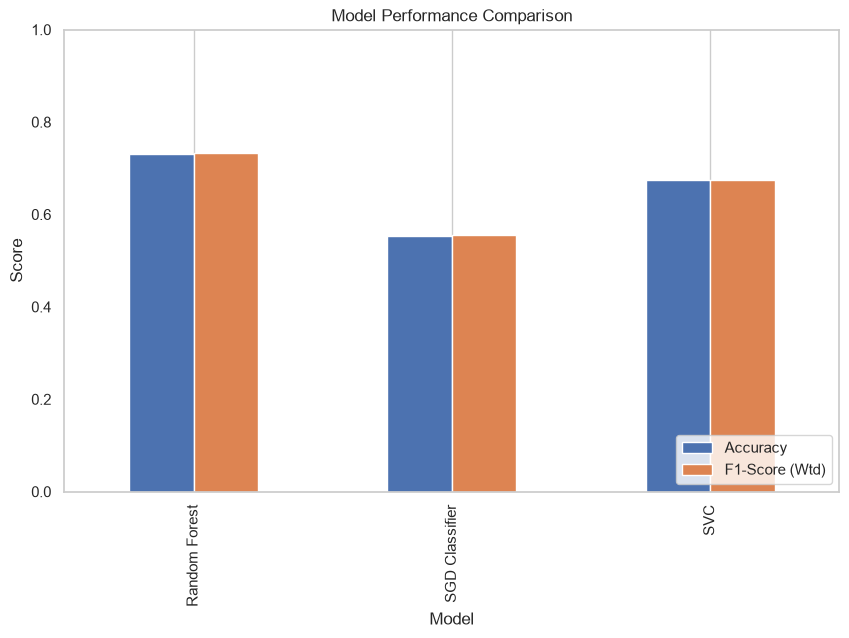

In [9]:
comparison_data=[]
for res in results:
    rep_dict= classification_report(y_test,res['Predictions'],output_dict=True)
    comparison_data.append({
        'Model': res['Model'],
        'Accuracy': res['Accuracy'],
        'Precision (Wtd)': rep_dict['weighted avg']['precision'],
        'Recall (Wtd)': rep_dict['weighted avg']['recall'],
        'F1-Score (Wtd)': rep_dict['weighted avg']['f1-score']
    })
comparison_df=pd.DataFrame(comparison_data).set_index('Model')
print("\nPerformance Comparison")
print(comparison_df)
plt.figure(figsize=(10,6))
comparison_df[['Accuracy', 'F1-Score (Wtd)']].plot(kind='bar',figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.grid(axis='y')
plt.show()

'''Conclusion: which model is most suitable for deployment and why?'''